Decision Tree Classifier(Iris Dataset)

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn import tree


Classes: ['setosa' 'versicolor' 'virginica']
Criterion=gini      Accuracy=100.00%
Criterion=entropy   Accuracy=100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Decision Tree Rules (first 20 lines):
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   | 

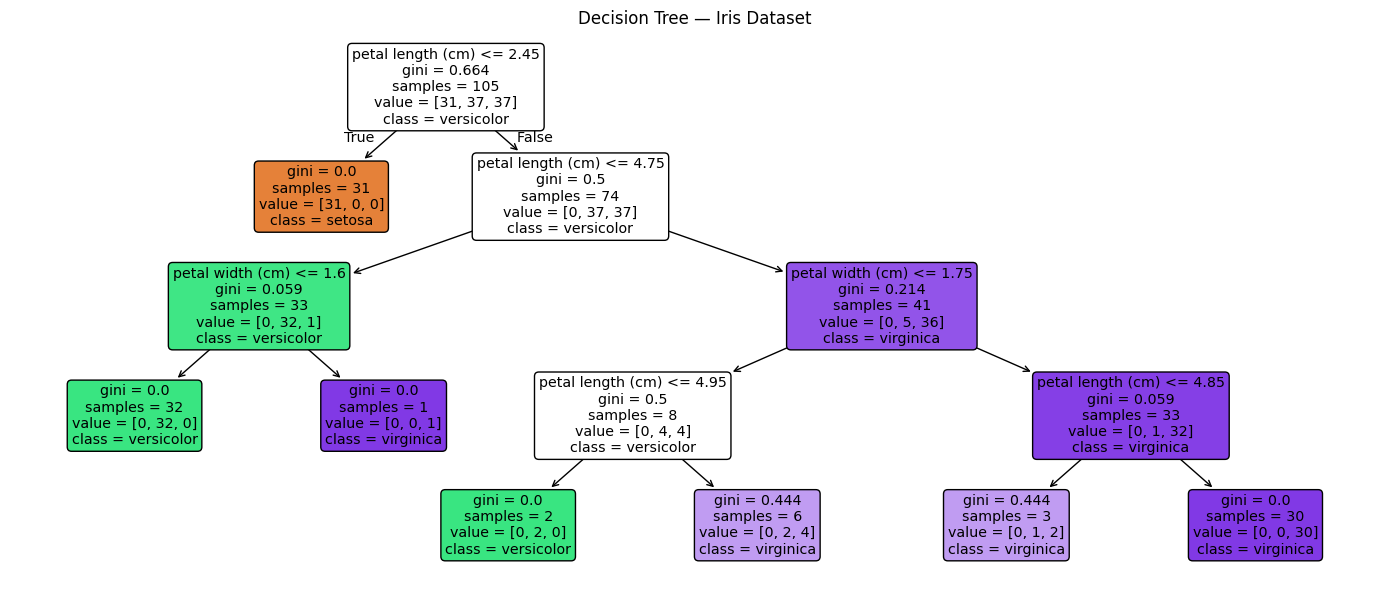

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names   = iris.target_names
print("Classes:", class_names)   # setosa, versicolor, virginica

# ---- Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# ---- Train: Try both criteria ----
for criterion in ['gini', 'entropy']:
    dt = DecisionTreeClassifier( criterion=criterion, max_depth=4, random_state=42 )
     # limit depth to prevent overfit

    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    print(f"Criterion={criterion:8s}  Accuracy={acc*100:.2f}%")

# ---- Final Model ----
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# ---- Print Tree as Text ----
tree_rules = export_text(dt_model, feature_names=list(feature_names))
print("Decision Tree Rules (first 20 lines):")
print('\n'.join(tree_rules.split('\n')[:20]))

# ---- Feature Importance ----
importance = dt_model.feature_importances_
print("\nFeature Importances:")
for name, imp in zip(feature_names, importance):
    bar = '█' * int(imp * 50)
    print(f"  {name:25s}: {imp:.4f} {bar}")

# ---- Visualize Tree ----
plt.figure(figsize=(14, 6))
tree.plot_tree(dt_model, feature_names=feature_names, class_names=class_names, filled=True, rounded=True)
plt.title('Decision Tree — Iris Dataset')
plt.tight_layout();
plt.savefig('decision_tree.png', dpi=100);
plt.show()

Decision Tree Purning

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split( iris.data, iris.target, test_size=0.3, random_state=42)
print("Effect of max_depth on Accuracy:")
print(f"{'max_depth':<12} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 35)

for depth in [1, 2, 3, 4, 5, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    tr = accuracy_score(y_train, dt.predict(X_train))
    te = accuracy_score(y_test,  dt.predict(X_test))
    print(f"{str(depth):<12} {tr*100:>9.1f}% {te*100:>9.1f}%")

Effect of max_depth on Accuracy:
max_depth     Train Acc   Test Acc
-----------------------------------
1                 64.8%      71.1%
2                 94.3%      97.8%
3                 95.2%     100.0%
4                 97.1%     100.0%
5                 99.0%     100.0%
None             100.0%     100.0%
